In [1]:
# Data handling libraries
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt

# For hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# For preprocessing
from sklearn.preprocessing import StandardScaler


In [2]:
# Load Titanic dataset
import seaborn as sns
df = sns.load_dataset("titanic")

# Display first 5 rows
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Select numerical features only (important for distance calculation)
# We are intentionally NOT using 'survived'
df_cluster = df[['age', 'fare', 'sibsp', 'parch']]

# Check missing values
df_cluster.isnull().sum()


age      177
fare       0
sibsp      0
parch      0
dtype: int64

In [4]:
# Fill missing values with median (robust method)
df_cluster['age'] = df_cluster['age'].fillna(df_cluster['age'].median())

# Confirm no missing values
df_cluster.isnull().sum()


C:\Users\amitm\AppData\Local\Temp\ipykernel_19188\467042733.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster['age'] = df_cluster['age'].fillna(df_cluster['age'].median())


age      0
fare     0
sibsp    0
parch    0
dtype: int64

In [5]:
# Create scaler object
scaler = StandardScaler()

# Scale the data
scaled_data = scaler.fit_transform(df_cluster)

# Convert back to DataFrame (optional, for readability)
scaled_df = pd.DataFrame(scaled_data, columns=df_cluster.columns)

scaled_df.head()


,age,fare,sibsp,parch
0,-0.565736,-0.502445,0.432793,-0.473674
1,0.663861,0.786845,0.432793,-0.473674
2,-0.258337,-0.488854,-0.474545,-0.473674
3,0.433312,0.420730,0.432793,-0.473674
4,0.433312,-0.486337,-0.474545,-0.473674


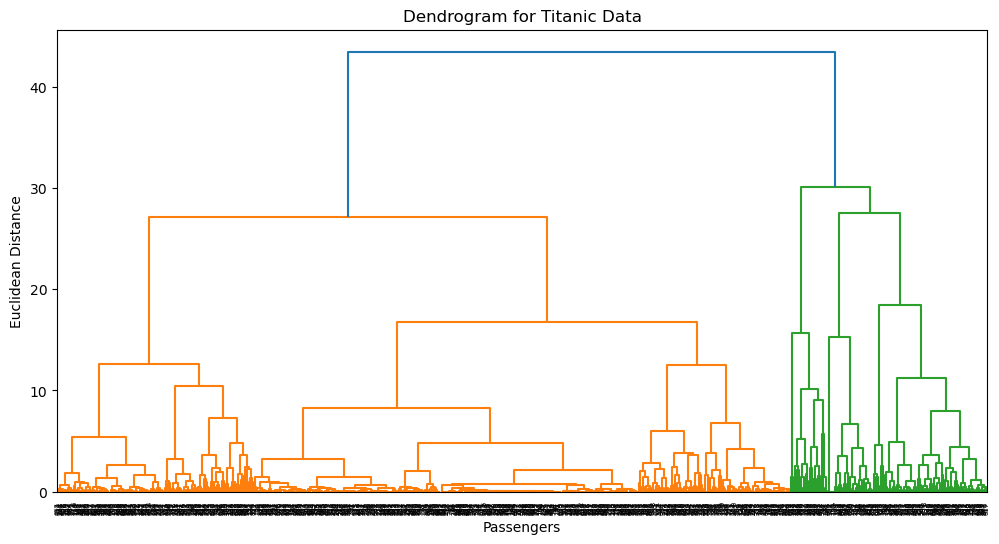

In [6]:
# Create linkage matrix using Ward method
linked = linkage(scaled_df, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogram for Titanic Data")
plt.xlabel("Passengers")
plt.ylabel("Euclidean Distance")
plt.show()


In [7]:
# Create Agglomerative Clustering model
hc_model = AgglomerativeClustering(
    n_clusters=3,        # chosen from dendrogram
    metric='euclidean',  # distance measure
    linkage='ward'       # linkage method
)

# Fit the model (NO y is used here)
cluster_labels = hc_model.fit_predict(scaled_df)


In [8]:
# Add cluster labels to original dataset
df_cluster['Cluster'] = cluster_labels

# View clustered data
df_cluster.head()


C:\Users\amitm\AppData\Local\Temp\ipykernel_19188\2345764023.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster['Cluster'] = cluster_labels


,age,fare,sibsp,parch,Cluster
0,22.0,7.2500,1,0,1
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,1


In [9]:
# Check how many data points in each cluster
df_cluster['Cluster'].value_counts()


Cluster
1    703
0    153
2     35
Name: count, dtype: int64

In [10]:
# Cluster-wise mean analysis
df_cluster.groupby('Cluster').mean()


,age,fare,sibsp,parch
Cluster,,,,
0,18.243464,29.056890,1.633987,1.686275
1,31.805121,23.715297,0.274538,0.051209
2,28.883429,216.468334,0.657143,1.314286


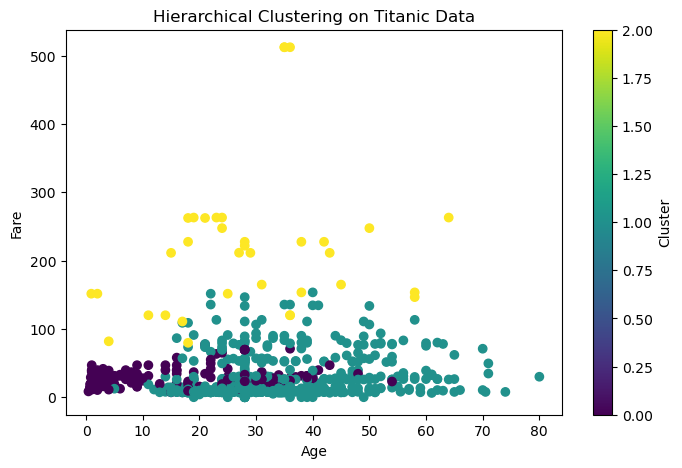

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(
    df_cluster['age'],
    df_cluster['fare'],
    c=df_cluster['Cluster'],
    cmap='viridis'
)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Hierarchical Clustering on Titanic Data")
plt.colorbar(label="Cluster")
plt.show()
